## Bayesian Causal Forest for HTE
**Model**: BCF for outcomes (probit link): model baseline μ(X) and treatment effect surface τ(X) with treatment A and include PS p(X) (or logit PS) as a covariate to correct for targeted selection.

BART is modelled with a PROBIT link function
$$Y_i = \mu_{i}(X, \hat{p}) + \tau_i(X) \cdot T_i$$

- $\mu(x_i, \pi_i)$ = the **prognostic function** — captures baseline outcome risk, regardless of treatment. $\pi_i$ are the propensity score estimates.
- $\tau(x_i)$ = the **treatment effect function** — captures how the treatment effect varies with covariates (this is CATE)
- $T \in {0,1}$ is the treatment indicator

In [1]:
import os
import sys
import seaborn as sns
from scipy.stats import norm
import pymc as pm
import pymc_bart as pmb
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from ISYE6420.Project.bcf_vis import build_ite_rd, plot_gates, build_clan_table, print_clan_table, build_ite_rd_inplace
rng = np.random.default_rng(123)

output_folder = "ISYE6420/Project/"

## Data Loading and Preparation

In [2]:
# Import configurations
dx_name = "copd"
version = "v7_040226"

cohort = pd.read_csv(f"ISYE6420\\Project\\data\\{dx_name}_severe_cohort.csv")
print(len(cohort))

114008


In [3]:
y = cohort["outcome"].values
treatment = cohort["exposure"].values
follow_up_time = cohort["follow_up_time"].values
# Convert to binary indicator for outcome
y_data = (y > 0).astype(int)


### 1. Prognostic Model $\mu(X, \hat{p})$

In [4]:
X = cohort.drop(columns=["patid", "outcome", "exposure", "follow_up_time", "weight", "ps_score"])
# convert True False columns to int
X = X.astype(int)
# Logit transform the propensity scores for better modeling
propensity_score = cohort["ps_score"]
eps = 1e-6
ps_values = np.clip(propensity_score, eps, 1 - eps)
logit_ps = np.log(ps_values / (1 - ps_values))
X['logit_ps'] = logit_ps
X_mu = X.values

prognostic_model_config = {
    "n_trees": 200,
    "beta_prior": 2,
    "alpha_prior": 0.95,
}

In [5]:
num_exac_pats = cohort[cohort['outcome'] > 0]['patid'].nunique()/ cohort['patid'].nunique()
print(f"Proportion of patients with at least one event: {num_exac_pats:.2%}")

Proportion of patients with at least one event: 1.47%


In [6]:
X.columns

Index(['age', 'gold_class', 'severe_exac_count', 't2dm_present',
       'num_treatments_baseline', 'num_outpatient_event', 'num_er_event',
       'days_since_last_severe_exac', 'Acute_IHD_flag', 'CAD_flag', 'PVD_flag',
       'atopic_disease_flag', 'ckd_flag', 'dyslipidemia_flag',
       'haemorrhagic_stroke_flag', 'heart_failure_flag', 'hypertension_flag',
       'ischemic_stroke_flag', 'obstructive_sleep_apnea_flag', 'smokers_flag',
       'Antibiotics_flag', 'ICS_LABA_flag', 'ICS_LABA_LAMA_flag',
       'LABA_LAMA_flag', 'LAMA_flag', 'OCS_flag', 'SABA_flag', 'bmi_20_25',
       'bmi_above_25', 'bmi_present', 'hba1c_missing', 'sex_Female',
       'region_Midwest', 'region_Northeast', 'region_South',
       'region_Southwest', 'region_West', 'logit_ps'],
      dtype='str')

### 2. $\tau$(X) Treatment Effect Model


In [7]:
# Treatment indicator as int
T = treatment.astype(int)

# Feature matrix for tau: same covariates as mu, but add treatment indicator instead of propensity score
#X["T"] = T
X_tau = X.values.astype(float)

tau_model_config = {
    "n_trees": 50,       # stronger regularisation toward zero for treatment effects
    "beta_prior": 3,     # more shrinkage towards homogenenous treatment effects
    "alpha_prior": 0.25,
}


## 3. Run Model

In [8]:
baseline_probit = norm.ppf(num_exac_pats)
# y_latent_mu = np.full(len(y_data), baseline_probit)
# y_latent_tau = np.random.normal(0, 0.1, size=len(y_data))

with pm.Model() as bcf_joint:

    X_mu_shared  = pm.Data("X_mu",  X_mu)
    X_tau_shared = pm.Data("X_tau", X_tau)
    T_shared = pm.Data("T", T.astype(float))
    y_obs = pm.Data("y_obs", y_data)

    # Prognosis model
    mu = pmb.BART(
        "mu",
        X_mu_shared,
        y_data.astype(float),
        m=prognostic_model_config["n_trees"],
        alpha=prognostic_model_config["alpha_prior"],
        beta=prognostic_model_config["beta_prior"],
        response="constant"
    )

    # Treatment effect
    tau = pmb.BART(
        "tau",
        X_tau_shared,
        y_data.astype(float),
        m=tau_model_config["n_trees"],
        alpha=tau_model_config["alpha_prior"],
        beta=tau_model_config["beta_prior"],
        response="constant"
    )

    # # Use a tight intercept prior to ensure the model starts with a reasonable baseline risk
    constant_intercept = norm.ppf(num_exac_pats)

    # The Latent Propensity
    eta = mu + tau * T_shared + constant_intercept
    
    # Bernoulli Likelihood with Probit link
    p = pm.math.invprobit(eta)
    y_likelihood = pm.Bernoulli("y_likelihood", p=p, observed=y_obs)

    trace_bcf = pm.sample(2000, tune=2000, nuts_sampler_kwargs={"target_accept": 0.9}, random_seed=rng, chains=4)

ppc = pm.sample_posterior_predictive(trace_bcf, model=bcf_joint)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>PGBART: [mu]
>PGBART: [tau]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 22714 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_likelihood]


Output()

In [9]:
# Extract CATTs from joint model
mu_joint  = trace_bcf.posterior["mu"].mean(dim=["chain", "draw"]).values
tau_joint = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values
tau_joint_sd = trace_bcf.posterior["tau"].std(dim=["chain", "draw"]).values

print(f"Joint CATT summary — mean: {tau_joint.mean():.4f}, sd: {tau_joint.std():.4f}")
print(f"ATT (treated only): {tau_joint[T == 1].mean():.4f}")

Joint CATT summary — mean: -0.2343, sd: 0.0761
ATT (treated only): -0.2279


In [10]:
az.to_netcdf(trace_bcf, f"{output_folder}bcf_{dx_name}_binary_severe_exac.nc")

'ISYE6420/Project/bcf_copd_binary_severe_exac.nc'

In [11]:
zero_ppc = (ppc.posterior_predictive["y_likelihood"] == 0).mean(dim=["chain", "draw"])
print(zero_ppc.values.mean())  # compare to actual zero rate

0.9858520103852362


## Load existing trace and compute CATE estimates

In [ ]:
#Load trace from nc file
trace_bcf = az.from_netcdf(f"{output_folder}bcf_{dx_name}_binary_severe_exac.nc")

In [9]:
with pm.Model() as bcf_joint:

    X_mu_shared  = pm.Data("X_mu",  X_mu)
    X_tau_shared = pm.Data("X_tau", X_tau)
    T_shared = pm.Data("T", T.astype(float))
    y_obs = pm.Data("y_obs", y_data)
    offset = pm.Data("offset", follow_up_time)

    # Prognosis model
    mu = pmb.BART(
        "mu",
        X_mu_shared,
        y_data.astype(float),
        m=prognostic_model_config["n_trees"],
        alpha=prognostic_model_config["alpha_prior"],
        beta=prognostic_model_config["beta_prior"],
        response="constant"
    )

    # Treatment effect
    tau = pmb.BART(
        "tau",
        X_tau_shared,
        y_data.astype(float),
        m=tau_model_config["n_trees"],
        alpha=tau_model_config["alpha_prior"],
        beta=tau_model_config["beta_prior"],
        response="constant"
    )

    # # Use a tight intercept prior to ensure the model starts with a reasonable baseline risk
    constant_intercept = norm.ppf(num_exac_pats)

    # The Latent Propensity
    eta = mu + tau * T_shared + constant_intercept
    
    # Bernoulli Likelihood with Probit link
    p = pm.math.invprobit(eta)
    y_likelihood = pm.Bernoulli("y_likelihood", p=p, observed=y_obs)

# Now you can run PPC using the trace loaded from the .nc file
with bcf_joint:
    ppc = pm.sample_posterior_predictive(trace_bcf)

Sampling: [y_likelihood]


Output()

In [12]:
summary = az.summary(trace_bcf, var_names=["tau"], filter_vars="like")
print(summary[summary["r_hat"] > 1.01].head(20))
print(f"\nMedian ESS (bulk): {summary['ess_bulk'].median():.0f}")
print(f"Patients with ESS < 100: {(summary['ess_bulk'] < 100).sum()}")

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau[2]  -0.345  0.120  -0.572   -0.120      0.004    0.002    1027.0   
tau[3]  -0.029  0.115  -0.236    0.194      0.004    0.002     917.0   
tau[4]  -0.176  0.126  -0.411    0.062      0.004    0.002     914.0   
tau[5]  -0.204  0.128  -0.439    0.040      0.019    0.003      47.0   
tau[6]  -0.275  0.117  -0.500   -0.060      0.004    0.003     971.0   
tau[7]  -0.243  0.124  -0.477   -0.007      0.004    0.002     953.0   
tau[8]  -0.264  0.129  -0.508   -0.026      0.008    0.003     275.0   
tau[10] -0.102  0.125  -0.333    0.147      0.004    0.002     950.0   
tau[13] -0.183  0.121  -0.400    0.050      0.004    0.002     924.0   
tau[14] -0.283  0.130  -0.525   -0.031      0.004    0.003     905.0   
tau[15] -0.203  0.116  -0.423    0.014      0.004    0.002    1036.0   
tau[18] -0.122  0.118  -0.340    0.101      0.009    0.002     166.0   
tau[19] -0.226  0.117  -0.448   -0.006      0.004    0.002    10

In [13]:
# Patients with <100 ESS in treated group
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau[0],-0.319,0.108,-0.522,-0.116,0.003,0.002,1045.0,1825.0,1.01
tau[1],-0.257,0.120,-0.478,-0.021,0.004,0.002,1006.0,1750.0,1.01
tau[2],-0.345,0.120,-0.572,-0.120,0.004,0.002,1027.0,1761.0,1.02
tau[3],-0.029,0.115,-0.236,0.194,0.004,0.002,917.0,1563.0,1.02
tau[4],-0.176,0.126,-0.411,0.062,0.004,0.002,914.0,1599.0,1.03
...,...,...,...,...,...,...,...,...,...
tau[114003],-0.255,0.127,-0.498,-0.019,0.004,0.003,980.0,1621.0,1.01
tau[114004],-0.203,0.129,-0.447,0.039,0.004,0.002,1065.0,1786.0,1.01
tau[114005],-0.226,0.133,-0.480,0.018,0.012,0.002,126.0,1343.0,1.05
tau[114006],-0.291,0.136,-0.552,-0.039,0.004,0.003,923.0,1485.0,1.04


In [14]:
def get_tau_samples(trace):
    """Flatten posterior tau samples → (total_draws, N)"""
    tau = trace.posterior["tau"].values          # (chains, draws, N)
    return tau.reshape(-1, tau.shape[-1])        # (4000, N)

def cate_summary(tau_flat, idx):
    """Return (mean, lo94, hi94, P(tau>0)) for a subgroup index array."""
    draws = tau_flat[:, idx].mean(axis=1)        # (total_draws,) — CATE posterior
    hdi = az.hdi(draws, hdi_prob=0.94)
    return draws.mean(), hdi[0], hdi[1], (draws > 0).mean()

In [15]:
# 1. Individual Level IRRs
tau_samples = get_tau_samples(trace_bcf) 
irr_samples = np.exp(tau_samples)

# Calculate Posterior Mean and 95% HDI for each patient
irr_mean = irr_samples.mean(axis=(0, 1))
irr_hdi = az.hdi(irr_samples, hdi_prob=0.95)

# 2. Overall CATT (on log-rate scale first, then summarized)
# Filter tau for treated patients only (T=1)
treated_indices = np.where(T == 1)[0]
catt_samples = tau_samples[:, treated_indices].mean(axis=1)  # (total_draws,) — CATT posterior for treated

catt_mean = catt_samples.mean()
catt_hdi = az.hdi(catt_samples, hdi_prob=0.95)

print(f"Overall CATT (log-scale): {catt_mean:.3f} 95% HDI {catt_hdi}")
print(f"Overall CATT (IRR scale): {np.exp(catt_mean):.3f}")

Overall CATT (log-scale): -0.228 95% HDI [-0.29288466 -0.1652591 ]
Overall CATT (IRR scale): 0.796


## Decision Tree Proxy for CATTs that are clinically interpretable

In [16]:
from sklearn.tree import DecisionTreeRegressor
# 1. Take the mean estimated treatment effect for each patient
catt_estimates = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values
sorted_catt = np.sort(catt_estimates)
catt_rate_ratios = np.exp(catt_estimates)
y_proxy = catt_estimates

# Drop region columns if they exist, since they are not clinically interpretable
administrative_cols = [col for col in X.columns if 'region' in col.lower() or 'site' in col.lower()]
X_tau_clinical = X.drop(columns=administrative_cols)
feature_names_clinical = X_tau_clinical.columns

# 2. Fit a shallow Decision Tree to explain these effects using your covariates
# Max depth 4 keeps it clinically interpretable (16 subgroups max)
proxy_tree = DecisionTreeRegressor(max_depth=4)
proxy_tree.fit(X_tau_clinical, y_proxy)

# 3. Get the feature importance and visualize the rules
feature_importance = proxy_tree.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": feature_names_clinical,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)
feature_importance_df.head(10).reset_index(drop=True)

,feature,importance
0,num_er_event,0.611244
1,smokers_flag,0.313736
2,gold_class,0.059270
3,CAD_flag,0.015750
4,age,0.000000
5,num_treatments_baseline,0.000000
6,num_outpatient_event,0.000000
7,days_since_last_severe_exac,0.000000
8,t2dm_present,0.000000
9,Acute_IHD_flag,0.000000


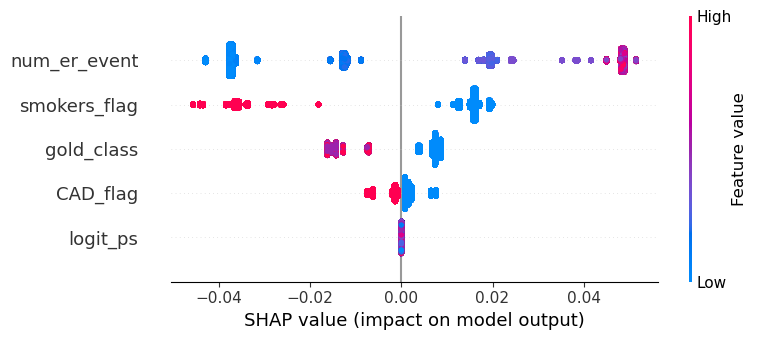

In [17]:
# SHAP values for the tree
import shap
explainer = shap.TreeExplainer(proxy_tree)
shap_values = explainer.shap_values(X_tau_clinical)

# Visualize the SHAP values
shap.summary_plot(shap_values, X_tau_clinical, feature_names=feature_names_clinical, max_display=5)


Building ITE-RD posterior arrays …
  ite_rd shape        : (8000, 114008)
  rd_treated shape    : (8000, 23059)
  mean(CATT)          : -0.00480

── A: GATES plot ──


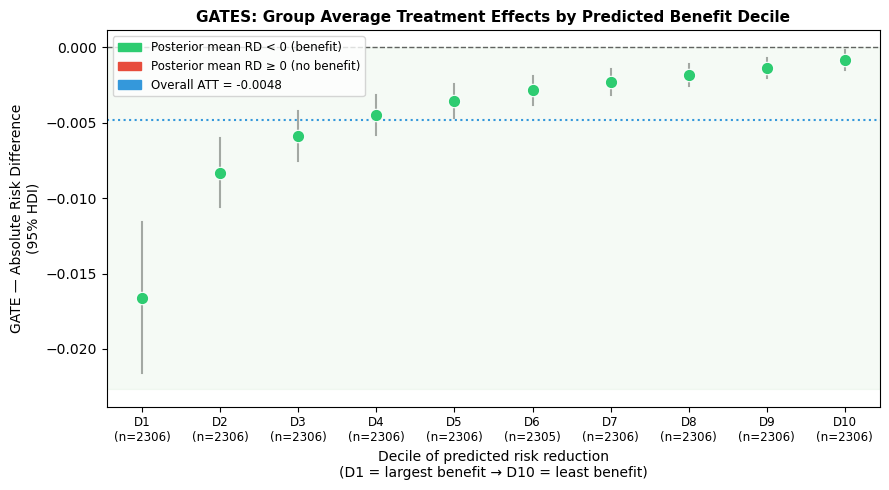

 decile    n  gate_mean        lo        hi  p_benefit
      1 2306  -0.016601 -0.021618 -0.011583   1.000000
      2 2306  -0.008361 -0.010612 -0.005982   1.000000
      3 2306  -0.005866 -0.007514 -0.004219   1.000000
      4 2306  -0.004472 -0.005812 -0.003174   1.000000
      5 2306  -0.003548 -0.004654 -0.002429   1.000000
      6 2305  -0.002846 -0.003850 -0.001911   1.000000
      7 2306  -0.002286 -0.003153 -0.001447   1.000000
      8 2306  -0.001818 -0.002591 -0.001068   1.000000
      9 2306  -0.001379 -0.002027 -0.000681   0.999875
     10 2306  -0.000834 -0.001470 -0.000175   0.994000


In [18]:
# ── Step 0: (Re)build ITE-RD posterior ───────────────────────────────
print("Building ITE-RD posterior arrays …")
ite_rd, rd_treated, mean_rd_treated, treated_mask = build_ite_rd_inplace(
    trace_bcf, X_mu, X_tau, T, constant_intercept)
print(f"  ite_rd shape        : {ite_rd.shape}")
print(f"  rd_treated shape    : {rd_treated.shape}")
print(f"  mean(CATT)          : {rd_treated.mean():.5f}")

# ── A: GATES ─────────────────────────────────────────────────────────
print("\n── A: GATES plot ──")
gates_df = plot_gates(
    rd_treated, mean_rd_treated,
    n_deciles=10,
    save_path="fig_gates_rd.png"
)
print(gates_df.to_string(index=False))


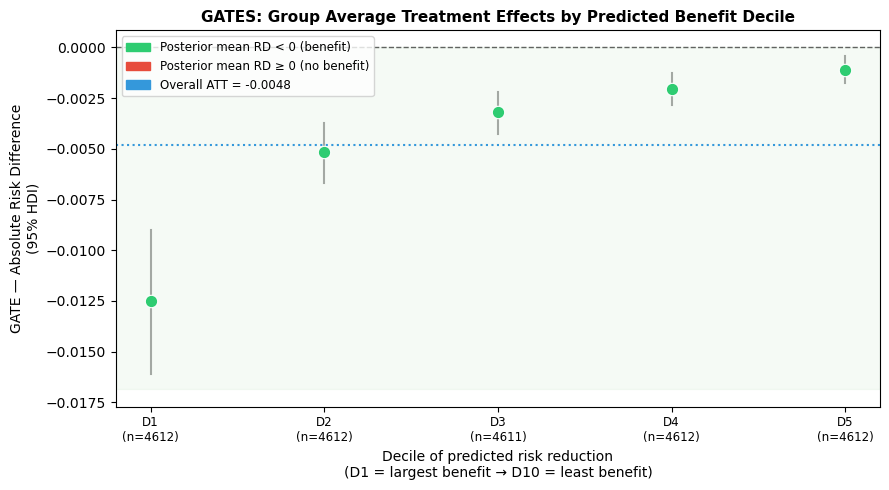

In [26]:
gates_df = plot_gates(
    rd_treated, mean_rd_treated,
    n_deciles=5,
    save_path="fig_gates_rd.png"
)

In [19]:
cohort

,age,gold_class,severe_exac_count,t2dm_present,num_treatments_baseline,num_outpatient_event,num_er_event,days_since_last_severe_exac,Acute_IHD_flag,CAD_flag,...,region_Northeast,region_South,region_Southwest,region_West,patid,exposure,follow_up_time,outcome,weight,ps_score
0,76.6789,1,0,True,0,6,4,-1,False,True,...,False,False,False,True,33039490433,True,364,0,1.000000,0.156220
1,67.9452,3,0,True,2,15,1,-1,False,True,...,False,True,False,False,33050133739,True,27,0,1.000000,0.223440
2,64.1752,3,0,True,1,14,0,-1,False,False,...,False,True,False,False,33063223087,True,254,0,1.000000,0.272955
3,63.3675,1,0,True,2,15,13,-1,False,False,...,False,True,False,False,33174597035,True,198,1,1.000000,0.456806
4,63.5865,3,0,True,1,30,10,-1,False,False,...,False,False,True,False,33277703500,True,85,0,1.000000,0.518348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114003,61.0294,1,0,True,3,0,0,-1,False,False,...,False,True,False,False,33215275187,False,164,0,0.065912,0.206490
114004,77.6399,1,0,True,2,0,0,-1,False,False,...,False,False,True,False,33058806956,False,130,0,0.049820,0.164363
114005,77.8754,2,0,False,3,0,0,-1,False,False,...,False,True,False,False,33062578829,False,228,0,0.019018,0.069839
114006,71.4496,1,0,True,1,0,0,-1,False,False,...,True,False,False,False,33187519747,False,364,0,0.008723,0.033292


In [20]:
# ── B: CLAN ──────────────────────────────────────────────────────────
print("\n── B: CLAN table ──")
clan_df = build_clan_table(
    mean_rd_treated, X, T,
    top_pct=0.10
)
print_clan_table(clan_df, top_pct=0.10)


── B: CLAN table ──

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  CLAN Table — Top 10% Maximum-Benefit Subgroup (D1) vs Rest of Treated
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Variable                             Type         D1 - high benefit (n=2306) Rest of treated (n=20753)   Absolute Difference                  SMD
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Unique Treatments - Baseline         continuous   2.76 ± 1.01                1.32 ± 1.09                                1.44                 1.38
SABA Use                             binary       53.5%                      16.7%                                      0.37                 0.83
Heart Failure                        binary  

In [21]:
clan_df = build_clan_table(
    mean_rd_treated, X, T,
    top_pct=0.90
)
print_clan_table(clan_df, top_pct=0.90)


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  CLAN Table — Top 90% Maximum-Benefit Subgroup (D1) vs Rest of Treated
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Variable                             Type         D1 - high benefit (n=20753) Rest of treated (n=2306)    Absolute Difference                  SMD
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Unique Treatments - Baseline         continuous   1.56 ± 1.16                0.60 ± 0.75                                0.96                 0.98
SABA Use                             binary       22.3%                      3.3%                                       0.19                 0.59
Heart Failure                        binary       34.8%          

In [22]:
X.columns

Index(['age', 'gold_class', 'severe_exac_count', 't2dm_present',
       'num_treatments_baseline', 'num_outpatient_event', 'num_er_event',
       'days_since_last_severe_exac', 'Acute_IHD_flag', 'CAD_flag', 'PVD_flag',
       'atopic_disease_flag', 'ckd_flag', 'dyslipidemia_flag',
       'haemorrhagic_stroke_flag', 'heart_failure_flag', 'hypertension_flag',
       'ischemic_stroke_flag', 'obstructive_sleep_apnea_flag', 'smokers_flag',
       'Antibiotics_flag', 'ICS_LABA_flag', 'ICS_LABA_LAMA_flag',
       'LABA_LAMA_flag', 'LAMA_flag', 'OCS_flag', 'SABA_flag', 'bmi_20_25',
       'bmi_above_25', 'bmi_present', 'hba1c_missing', 'sex_Female',
       'region_Midwest', 'region_Northeast', 'region_South',
       'region_Southwest', 'region_West', 'logit_ps'],
      dtype='str')

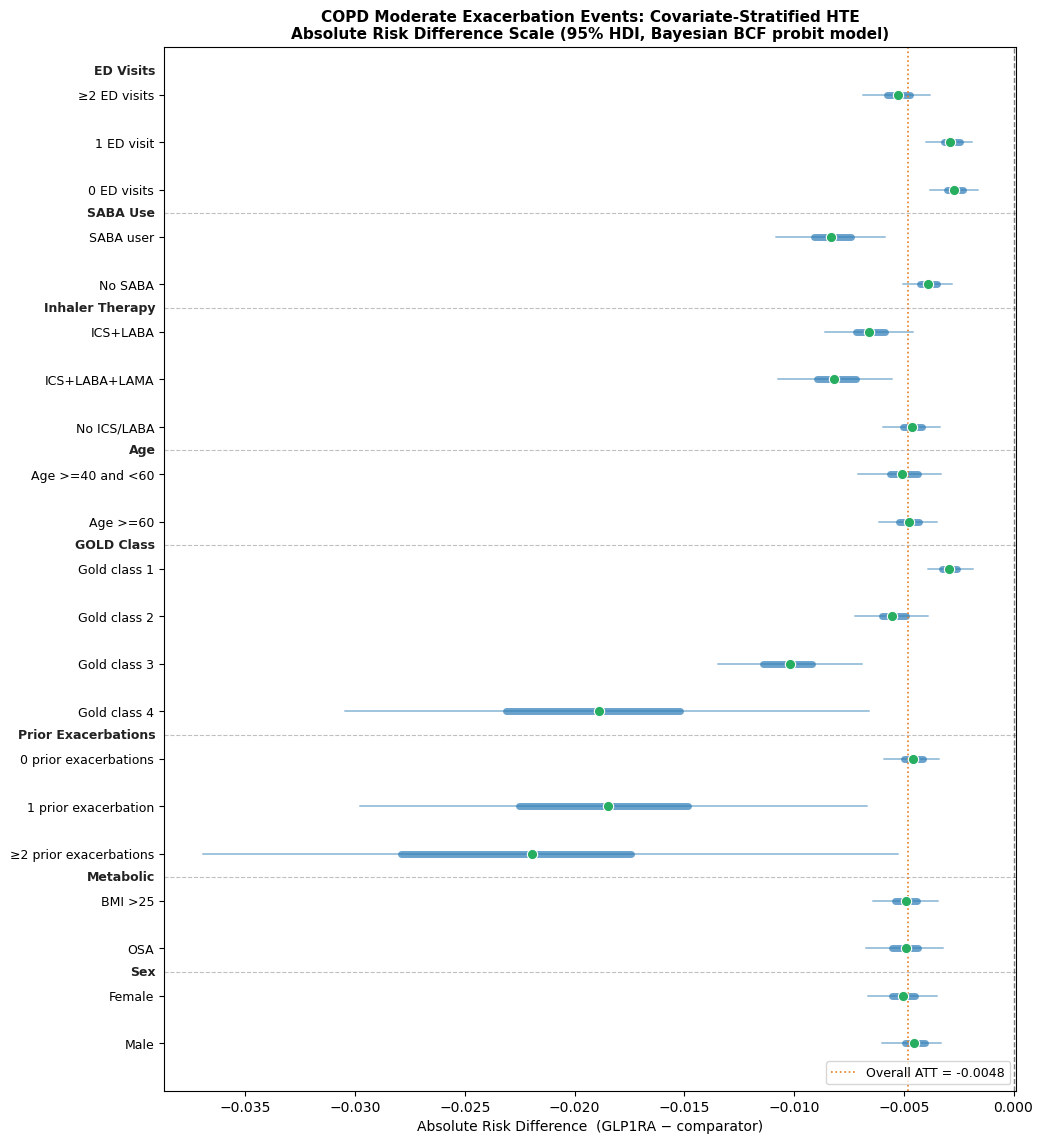

              group                  label     n      mean      lo95      hi95  p_benefit
          ED Visits           ≥2 ED visits 18554 -0.005285 -0.006868 -0.003798   1.000000
          ED Visits             1 ED visit  2291 -0.002903 -0.003986 -0.001871   1.000000
          ED Visits            0 ED visits  2214 -0.002709 -0.003803 -0.001631   1.000000
           SABA Use              SABA user  4707 -0.008299 -0.010825 -0.005855   1.000000
           SABA Use                No SABA 18352 -0.003904 -0.005032 -0.002813   1.000000
    Inhaler Therapy               ICS+LABA  2090 -0.006566 -0.008598 -0.004586   1.000000
    Inhaler Therapy          ICS+LABA+LAMA  3535 -0.008171 -0.010747 -0.005542   1.000000
    Inhaler Therapy            No ICS/LABA 20969 -0.004625 -0.005940 -0.003328   1.000000
                Age       Age >=40 and <60  3390 -0.005091 -0.007063 -0.003321   1.000000
                Age               Age >=60 19669 -0.004751 -0.006142 -0.003493   1.000000
         G

In [24]:
# ══════════════════════════════════════════════════════════════════════════
# CELL C — HTE Forest Plot on the absolute Risk Difference scale
# Assumes: ite_rd, X, T, constant_intercept are in scope from Cell A
# ══════════════════════════════════════════════════════════════════════════

def rd_stratum(ite_rd, full_mask, T_arr, hdi_prob=0.95):
    """CATE among treated patients within full_mask."""
    mask = full_mask & T_arr.astype(bool)
    if mask.sum() < 20:
        return None
    draws      = ite_rd[:, mask].mean(axis=1)
    hdi_v      = az.hdi(draws, hdi_prob=hdi_prob)
    lo50, hi50 = az.hdi(draws, hdi_prob=0.50)
    return dict(mean=draws.mean(), lo95=hdi_v[0], hi95=hdi_v[1],
                lo50=lo50, hi50=hi50,
                p_benefit=float((draws < 0).mean()), n=int(mask.sum()))

Xd = X.reset_index(drop=True)

strata = [
    ("≥2 ED visits",          "ED Visits",          (Xd["num_er_event"] >= 2).values),
    ("1 ED visit",            "ED Visits",          (Xd["num_er_event"] == 1).values),
    ("0 ED visits",           "ED Visits",          (Xd["num_er_event"] == 0).values),
    ("SABA user",             "SABA Use",           (Xd["SABA_flag"] == 1).values),
    ("No SABA",               "SABA Use",           (Xd["SABA_flag"] == 0).values),
    ("ICS+LABA",              "Inhaler Therapy",    (Xd["ICS_LABA_flag"] == 1).values),
    ("ICS+LABA+LAMA",         "Inhaler Therapy",    ((Xd["ICS_LABA_LAMA_flag"]==1)).values),
    ("No ICS/LABA",           "Inhaler Therapy",    (Xd["ICS_LABA_flag"] == 0).values),
    ("Age >=18 and <40",       "Age",               ((Xd["age"] >= 18) & (Xd["age"] < 40)).values),
    ("Age >=40 and <60",       "Age",               ((Xd["age"] >= 40) & (Xd["age"] < 60)).values),
    ("Age >=60",               "Age",               (Xd["age"] >= 60).values),
    ("Gold class 1",           "GOLD Class",        (Xd["gold_class"] == 1).values),
    ("Gold class 2",         "GOLD Class",          (Xd["gold_class"] == 2).values),
    ("Gold class 3",         "GOLD Class",          (Xd["gold_class"] == 3).values),
    ("Gold class 4",           "GOLD Class",        (Xd["gold_class"] == 4).values),
    ("0 prior exacerbations", "Prior Exacerbations",(Xd["severe_exac_count"] == 0).values),
    ("1 prior exacerbation",  "Prior Exacerbations",(Xd["severe_exac_count"] == 1).values),
    ("≥2 prior exacerbations","Prior Exacerbations",(Xd["severe_exac_count"] >= 2).values),
    ("BMI >25",               "Metabolic",          (Xd["bmi_above_25"] == 1).values),
    ("OSA",                   "Metabolic",          (Xd["obstructive_sleep_apnea_flag"]==1).values),
    ("Female",                "Sex",                (Xd["sex_Female"] == 1).values),
    ("Male",                  "Sex",                (Xd["sex_Female"] == 0).values),
]

rows = []
for label, group, mask in strata:
    r = rd_stratum(ite_rd, mask, T)
    if r:
        rows.append({"label": label, "group": group, **r})

forest_df = pd.DataFrame(rows)

# ── Draw ──────────────────────────────────────────────────────────────────
n_r    = len(forest_df)
colour = "#2c7bb6"
fig, ax = plt.subplots(figsize=(11, max(6, 0.55 * n_r + 2)))

y_pos          = np.arange(n_r)[::-1]
current_group  = None

for i, (_, row) in enumerate(forest_df.iterrows()):
    y = y_pos[i]
    if row["group"] != current_group:
        current_group = row["group"]
        # add line break and group label
        if i > 0:
            ax.axhline(y + 0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
        ax.text(-0.01, y + 0.5, row["group"],
                transform=ax.get_yaxis_transform(),
                ha="right", va="center",
                fontsize=9, fontweight="bold", color="#222222")
        # add more space above and below group label

    ax.plot([row["lo95"], row["hi95"]], [y, y],
            color=colour, lw=1.4, alpha=0.45, solid_capstyle="round")
    ax.plot([row["lo50"], row["hi50"]], [y, y],
            color=colour, lw=5,   alpha=0.70, solid_capstyle="round")
    dot_c = "#27ae60" if row["mean"] < 0 else "#e74c3c"
    ax.scatter(row["mean"], y, s=55, color=dot_c, zorder=5,
               edgecolors="white", linewidths=0.8)
    # ax.text(forest_df["hi95"].max() + 0.001, y,
    #         f"  {row['mean']:+.4f} [{row['lo95']:+.4f}, {row['hi95']:+.4f}]  "
    #         f"P(benefit)={row['p_benefit']:.2f}  n={row['n']}",
    #         va="center", fontsize=7.5, color="gray")

att_mean = ite_rd[:, T.astype(bool)].mean()
ax.axvline(0,        color="black",   lw=1,   ls="--", alpha=0.5)
ax.axvline(att_mean, color="#e67e22", lw=1.2, ls=":",
           label=f"Overall ATT = {att_mean:.4f}")

ax.set_yticks(y_pos)
ax.set_yticklabels(forest_df["label"].tolist(), fontsize=9)
ax.set_xlabel(
    "Absolute Risk Difference  (GLP1RA − comparator)",
    fontsize=10)
ax.set_title(
    "COPD Moderate Exacerbation Events: Covariate-Stratified HTE\n"
    "Absolute Risk Difference Scale (95% HDI, Bayesian BCF probit model)",
    fontsize=11, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
#fig.tight_layout()
plt.show()
print(forest_df[["group","label","n","mean","lo95","hi95","p_benefit"]].to_string(index=False))

In [25]:
from scipy.special import ndtr 
def build_ite_rd_with_intervals(trace, X_mu_arr, X_tau_arr, T_arr, constant_intercept, chunk_size=500):
    N = X_mu_arr.shape[0]
    mu_s  = trace.posterior["mu"].values.reshape(-1, N)   
    tau_s = trace.posterior["tau"].values.reshape(-1, N)  
    D = mu_s.shape[0]

    treated_mask = T_arr.astype(bool)
    
    # Pre-allocate a tiny array to hold the overall CATT per draw (Shape: 8000,)
    catt_rd_posterior = np.zeros(D)
    
    for i in range(0, D, chunk_size):
        end = min(i + chunk_size, D)
        
        mu_chunk = mu_s[i:end]
        tau_chunk = tau_s[i:end]
        
        eta_0 = mu_chunk + constant_intercept
        eta_1 = mu_chunk + tau_chunk + constant_intercept
        chunk_rd = ndtr(eta_1) - ndtr(eta_0)
        
        # Calculate the mean across treated individuals for this batch of draws
        catt_rd_posterior[i:end] = chunk_rd[:, treated_mask].mean(axis=1)
        
    return catt_rd_posterior

# 1. Run the updated memory-safe function
catt_rd_posterior = build_ite_rd_with_intervals(trace_bcf, X_mu, X_tau, T, constant_intercept)

# 2. Compute actual HDI using ArviZ (or stick to your np.quantile code)
hdi_intervals = az.hdi(catt_rd_posterior, hdi_prob=0.95)

print(f"CATT (Risk Difference) Mean: {catt_rd_posterior.mean():.4f}")
print(f"CATT (Risk Difference) 95% HDI: [{hdi_intervals[0]:.4f}, {hdi_intervals[1]:.4f}]")

CATT (Risk Difference) Mean: -0.0048
CATT (Risk Difference) 95% HDI: [-0.0061, -0.0034]
